# 🏦 신용카드 발급 승인 예측 - 데이터 파악
> Kaggle Credit Card Approval Prediction 데이터셋

---
### 📋 목차
1. 라이브러리 임포트
2. 데이터 로드
3. 기본 정보 확인
4. 결측값 확인
5. 타겟 컬럼 생성 (두 파일 합치기)
6. 데이터 시각화 (EDA)
7. 데이터 저장

## 1. 라이브러리 임포트

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Mac)
matplotlib.rc('font', family='AppleGothic')
matplotlib.rc('axes', unicode_minus=False)

print('✅ 라이브러리 임포트 완료')

✅ 라이브러리 임포트 완료


## 2. 데이터 로드
> Kaggle에서 다운로드한 두 파일을 로드합니다.
> - `application_record.csv` : 고객 신상정보
> - `credit_record.csv` : 신용 기록

In [2]:
# 파일 경로를 환경에 맞게 수정
app = pd.read_csv('application_record.csv')
credit = pd.read_csv('credit_record.csv')

print(f'✅ application_record: {app.shape[0]:,}행, {app.shape[1]}열')
print(f'✅ credit_record: {credit.shape[0]:,}행, {credit.shape[1]}열')

✅ application_record: 438,557행, 18열
✅ credit_record: 1,048,575행, 3열


## 3. 기본 정보 확인

In [3]:
# application_record 첫 5행
print('=== application_record 상위 5행 ===')
app.head()

=== application_record 상위 5행 ===


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [4]:
# credit_record 첫 5행
print('=== credit_record 상위 5행 ===')
credit.head()

=== credit_record 상위 5행 ===


,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [5]:
# 컬럼별 타입 및 결측값 확인
print('=== application_record 컬럼 정보 ===')
app.info()

=== application_record 컬럼 정보 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-nul

In [6]:
# 수치형 컬럼 기초 통계
print('=== application_record 기초 통계 ===')
app.describe()

=== application_record 기초 통계 ===


,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,4.385570e+05,438557.000000,4.385570e+05,438557.000000,438557.000000,438557.0,438557.000000,438557.000000,438557.000000,438557.000000
mean,6.022176e+06,0.427390,1.875243e+05,-15997.904649,60563.675328,1.0,0.206133,0.287771,0.108207,2.194465
std,5.716370e+05,0.724882,1.100869e+05,4185.030007,138767.799647,0.0,0.404527,0.452724,0.310642,0.897207
min,5.008804e+06,0.000000,2.610000e+04,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,5.609375e+06,0.000000,1.215000e+05,-19483.000000,-3103.000000,1.0,0.000000,0.000000,0.000000,2.000000
50%,6.047745e+06,0.000000,1.607805e+05,-15630.000000,-1467.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,6.456971e+06,1.000000,2.250000e+05,-12514.000000,-371.000000,1.0,0.000000,1.000000,0.000000,3.000000
max,7.999952e+06,19.000000,6.750000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000


In [7]:
# 범주형 컬럼 고유값 확인
cat_cols = app.select_dtypes(include='object').columns
print('=== 범주형 컬럼 고유값 ===')
for col in cat_cols:
    print(f'\n[{col}]')
    print(app[col].value_counts())

=== 범주형 컬럼 고유값 ===

[CODE_GENDER]
CODE_GENDER
F    294440
M    144117
Name: count, dtype: int64

[FLAG_OWN_CAR]
FLAG_OWN_CAR
N    275459
Y    163098
Name: count, dtype: int64

[FLAG_OWN_REALTY]
FLAG_OWN_REALTY
Y    304074
N    134483
Name: count, dtype: int64

[NAME_INCOME_TYPE]
NAME_INCOME_TYPE
Working                 226104
Commercial associate    100757
Pensioner                75493
State servant            36186
Student                     17
Name: count, dtype: int64

[NAME_EDUCATION_TYPE]
NAME_EDUCATION_TYPE
Secondary / secondary special    301821
Higher education                 117522
Incomplete higher                 14851
Lower secondary                    4051
Academic degree                     312
Name: count, dtype: int64

[NAME_FAMILY_STATUS]
NAME_FAMILY_STATUS
Married                 299828
Single / not married     55271
Civil marriage           36532
Separated                27251
Widow                    19675
Name: count, dtype: int64

[NAME_HOUSING_TYPE]
NAME_HOUSI

## 4. 결측값 확인

In [8]:
# 결측값 수 및 비율
missing = app.isnull().sum()
missing_pct = (missing / len(app) * 100).round(2)
missing_df = pd.DataFrame({'결측값 수': missing, '결측 비율(%)': missing_pct})
missing_df = missing_df[missing_df['결측값 수'] > 0].sort_values('결측값 수', ascending=False)

if len(missing_df) == 0:
    print('✅ 결측값 없음')
else:
    print(missing_df)

                  결측값 수  결측 비율(%)
OCCUPATION_TYPE  134203      30.6


## 5. 타겟 컬럼 생성 (두 파일 합치기)
> **STATUS 컬럼 의미**
> - `C` : 해당 월 상환 완료 (정상)
> - `X` : 해당 월 대출 없음 (정상)
> - `0` : 1~29일 연체
> - `1` : 30~59일 연체
> - `2~5` : 60일 이상 연체
>
> → **1, 2, 3, 4, 5** 이면 연체(거절) = 1, 나머지는 정상(승인) = 0

In [9]:
# 타겟 컬럼 생성
credit['TARGET'] = credit['STATUS'].apply(
    lambda x: 1 if x in ['1', '2', '3', '4', '5'] else 0
)

# 고객별 최악 상태 기준으로 집계 (한 번이라도 연체 = 1)
credit_agg = credit.groupby('ID')['TARGET'].max().reset_index()

print(f'✅ 타겟 생성 완료')
print(credit_agg['TARGET'].value_counts())

✅ 타겟 생성 완료
TARGET
0    40635
1     5350
Name: count, dtype: int64


In [10]:
# 두 파일 합치기
df = app.merge(credit_agg, on='ID', how='inner')

print(f'✅ 병합 완료: {df.shape[0]:,}행, {df.shape[1]}열')
df.head()

✅ 병합 완료: 36,457행, 19열


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0


## 6. 데이터 시각화 (EDA)

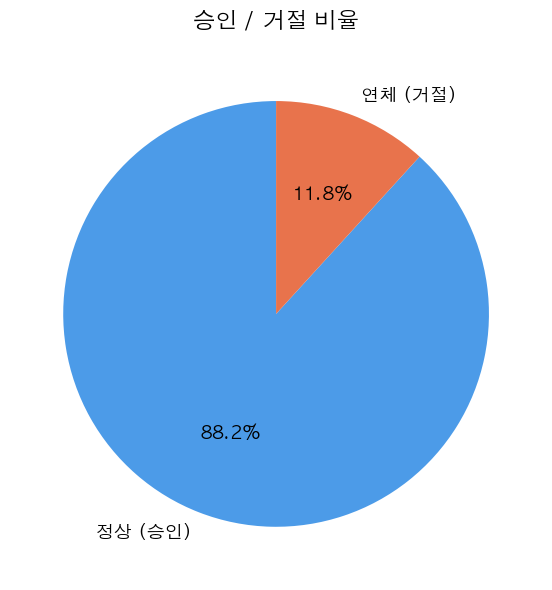

✅ 저장: plot_01_target_ratio.png


In [ ]:
# 1. 승인 / 거절 비율
fig, ax = plt.subplots(figsize=(6, 6))
counts = df['TARGET'].value_counts()
labels = ['정상 (승인)', '연체 (거절)']
colors = ['#4C9BE8', '#E8734C']

ax.pie(counts, labels=labels, autopct='%1.1f%%', colors=colors,
       startangle=90, textprops={'fontsize': 13})
ax.set_title('승인 / 거절 비율', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot_01_target_ratio.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 저장: plot_01_target_ratio.png')

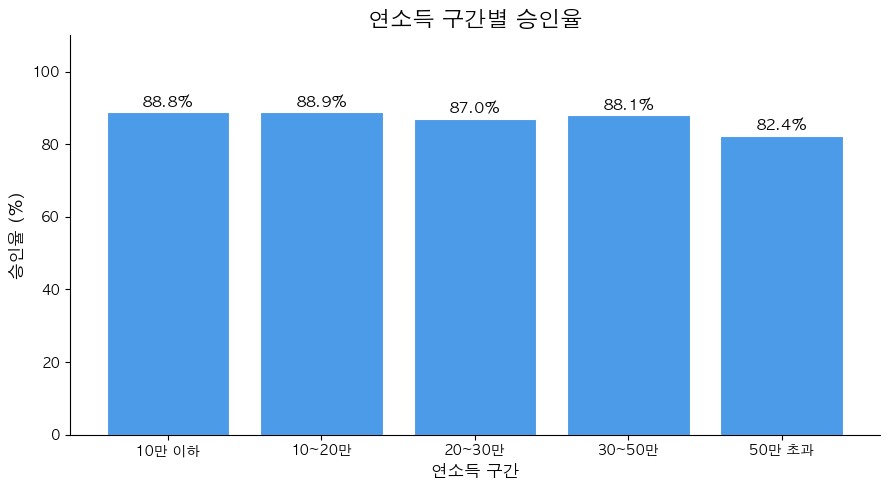

✅ 저장: plot_02_income_approval.png


In [ ]:
# 2. 연소득 구간별 승인율
df['소득구간'] = pd.cut(df['AMT_INCOME_TOTAL'],
                        bins=[0, 100000, 200000, 300000, 500000, float('inf')],
                        labels=['10만 이하', '10~20만', '20~30만', '30~50만', '50만 초과'])

income_approval = df.groupby('소득구간')['TARGET'].apply(
    lambda x: (x == 0).sum() / len(x) * 100
).reset_index()
income_approval.columns = ['소득구간', '승인율(%)']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(income_approval['소득구간'], income_approval['승인율(%)'],
              color='#4C9BE8', edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, income_approval['승인율(%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11)

ax.set_title('연소득 구간별 승인율', fontsize=16, fontweight='bold')
ax.set_xlabel('연소득 구간', fontsize=12)
ax.set_ylabel('승인율 (%)', fontsize=12)
ax.set_ylim(0, 110)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('plot_02_income_approval.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 저장: plot_02_income_approval.png')

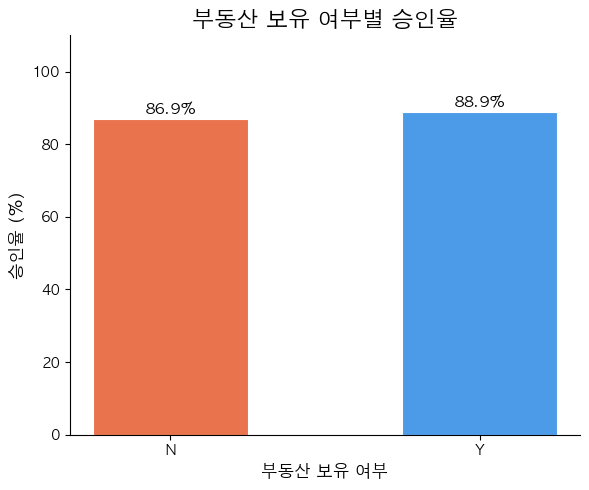

✅ 저장: plot_03_realty_approval.png


In [ ]:
# 3. 신용기록 보유 여부에 따른 승인율
# FLAG_OWN_REALTY 또는 다른 신용 관련 컬럼 활용

if 'FLAG_OWN_REALTY' in df.columns:
    col = 'FLAG_OWN_REALTY'
    label = '부동산 보유 여부'
elif 'FLAG_OWN_CAR' in df.columns:
    col = 'FLAG_OWN_CAR'
    label = '자동차 보유 여부'
else:
    col = df.select_dtypes(include='object').columns[0]
    label = col

realty_approval = df.groupby(col)['TARGET'].apply(
    lambda x: (x == 0).sum() / len(x) * 100
).reset_index()
realty_approval.columns = [label, '승인율(%)']

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(realty_approval[label], realty_approval['승인율(%)'],
              color=['#E8734C', '#4C9BE8'], edgecolor='white', linewidth=0.8, width=0.5)

for bar, val in zip(bars, realty_approval['승인율(%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11)

ax.set_title(f'{label}별 승인율', fontsize=16, fontweight='bold')
ax.set_xlabel(label, fontsize=12)
ax.set_ylabel('승인율 (%)', fontsize=12)
ax.set_ylim(0, 110)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('plot_03_realty_approval.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 저장: plot_03_realty_approval.png')

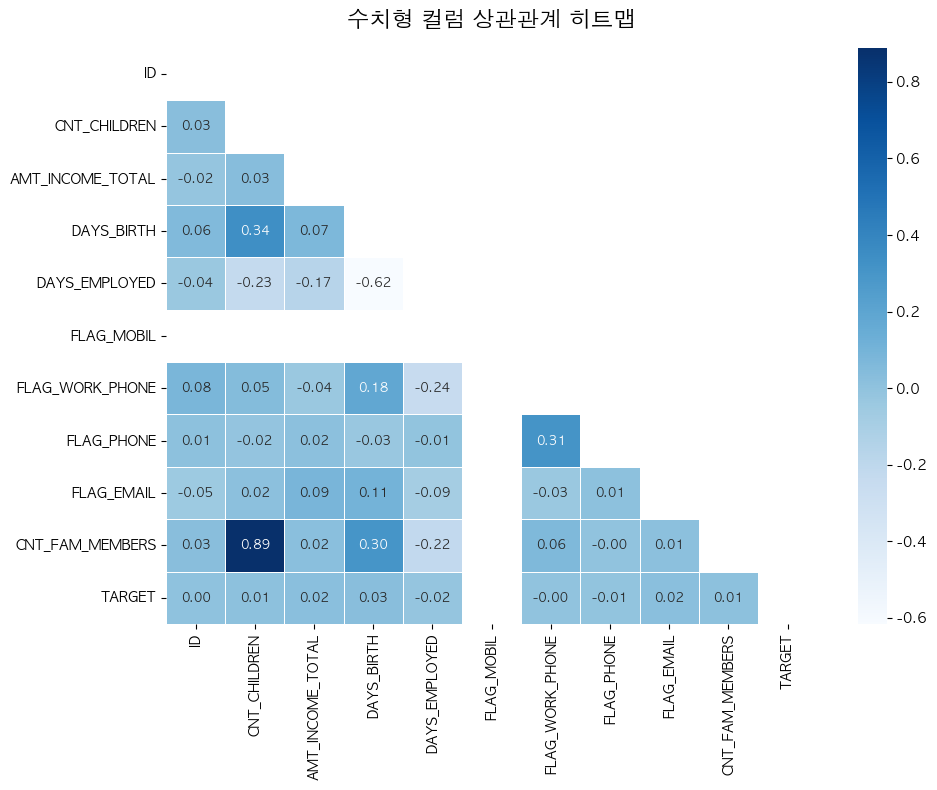

✅ 저장: plot_04_heatmap.png


In [ ]:
# 4. 상관관계 히트맵 (수치형 컬럼)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

fig, ax = plt.subplots(figsize=(10, 8))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('수치형 컬럼 상관관계 히트맵', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot_04_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 저장: plot_04_heatmap.png')

## 7. 데이터 저장
> MLTable 형식 변환을 위해 전처리된 데이터를 CSV로 저장합니다.

In [15]:
# ID 컬럼 제거 후 저장 (모델링에 불필요)
df_final = df.drop(columns=['ID'])

df_final.to_csv('credit_card_data.csv', index=False)

print(f'✅ 저장 완료: credit_card_data.csv')
print(f'   - 행 수: {df_final.shape[0]:,}')
print(f'   - 열 수: {df_final.shape[1]}')
print(f'   - 타겟 분포:\n{df_final["TARGET"].value_counts()}')

✅ 저장 완료: credit_card_data.csv
   - 행 수: 36,457
   - 열 수: 19
   - 타겟 분포:
TARGET
0    32166
1     4291
Name: count, dtype: int64


---
## 다음 단계
1. `credit_card_data.csv` 와 같은 폴더에 `MLTable` 파일 생성
2. Azure ML 스튜디오에 데이터 업로드
3. AutoML 실험 실행